In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
# dataset sintético
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: torch.Size([800, 20])
Forma de y_train: torch.Size([800, 1])
Forma de X_test: torch.Size([200, 20])
Forma de y_test: torch.Size([200, 1])


In [30]:
class SimplesNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimplesNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  # Camada oculta
        self.relu = nn.ReLU()  # Ativação ReLU
        self.fc2 = nn.Linear(hidden_size, output_size)  # Camada de saída
        self.sigmoid = nn.Sigmoid()  # Ativação sigmoid para classificação binária

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

# Hiperparâmetros
input_size = 20  # Número de features
hidden_size = 10  # Neurônios na camada oculta
output_size = 1  # Saída binária (0 ou 1)
# Instanciar a rede
model = SimplesNN(input_size, hidden_size, output_size)

In [ ]:
criterion = nn.BCELoss()  
optimizer = optim.Adam(model.parameters(), lr=0.01) 

Época [1/10], Perda: 0.7017
Época [2/10], Perda: 0.6867
Época [3/10], Perda: 0.6725
Época [4/10], Perda: 0.6590
Época [5/10], Perda: 0.6460
Época [6/10], Perda: 0.6334
Época [7/10], Perda: 0.6211
Época [8/10], Perda: 0.6088
Época [9/10], Perda: 0.5966
Época [10/10], Perda: 0.5844


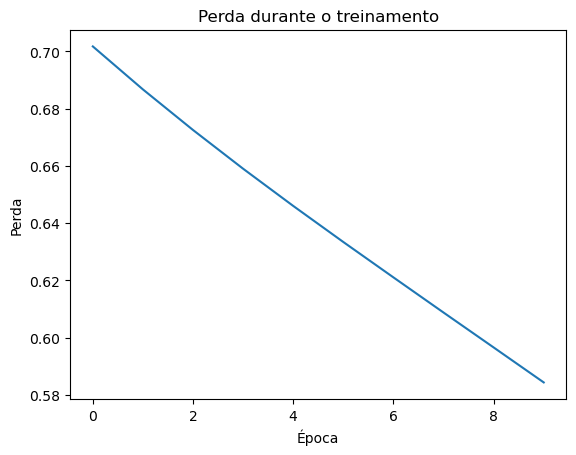

In [24]:
num_epochs = 10  # Número de épocas
losses = []  # Para armazenar as perdas

for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward pass e otimização
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    print(f"Época [{epoch+1}/{num_epochs}], Perda: {loss.item():.4f}")

# Plotar a perda ao longo das épocas
plt.plot(losses)
plt.xlabel("Época")
plt.ylabel("Perda")
plt.title("Perda durante o treinamento")
plt.show()

In [25]:
# Salvar os pesos do modelo
torch.save(model.state_dict(), "model_weights.pth")
print("Pesos do modelo salvos em 'model_weights.pth'")

Pesos do modelo salvos em 'model_weights.pth'


In [ ]:
# Criar uma nova instância do modelo
loaded_model = SimplesNN(input_size, hidden_size, output_size)
# Carregar os pesos salvos
loaded_model.load_state_dict(torch.load("model_weights.pth"))
# Colocar o modelo em modo de avaliação
loaded_model.eval()
with torch.no_grad():
    outputs = loaded_model(X_test)
    predicted = (outputs > 0.5).float()  
    accuracy = (predicted == y_test).float().mean()
    print(f"Acurácia no teste: {accuracy.item() * 100:.2f}%")

Acurácia no teste: 77.50%


In [ ]:

pesos_carregados = torch.load("model_weights.pth")
print("Conteúdo do arquivo model_weights.pth:")
print(pesos_carregados)

Conteúdo do arquivo model_weights.pth:
OrderedDict([('fc1.weight', tensor([[-0.0604, -0.0431, -0.1999,  0.0823, -0.2104, -0.1520, -0.1246,  0.1098,
          0.1431,  0.2078,  0.0319, -0.2049, -0.2367,  0.1313, -0.1335, -0.0792,
         -0.0140,  0.0650,  0.1878, -0.0558],
        [ 0.2379,  0.0130,  0.2215, -0.2714, -0.0865, -0.0605, -0.0796, -0.0725,
          0.2611,  0.1211, -0.1012,  0.1709, -0.1185,  0.0146,  0.0887, -0.1108,
         -0.2233,  0.1313, -0.0140, -0.1463],
        [ 0.2112, -0.0107,  0.0691, -0.0969,  0.2475,  0.2523, -0.1573, -0.1798,
         -0.0238, -0.2624,  0.3002,  0.0351, -0.2137,  0.1589, -0.3016,  0.0794,
         -0.2221, -0.0729, -0.1489,  0.0873],
        [ 0.2778,  0.0228,  0.0665, -0.1374, -0.1491,  0.0126,  0.1276,  0.1887,
          0.1432, -0.0850, -0.1301, -0.0960, -0.2427, -0.1287,  0.0551,  0.2086,
         -0.0585,  0.0058, -0.0857, -0.0405],
        [-0.0198, -0.2139, -0.2004,  0.0699, -0.0321,  0.1802, -0.0400, -0.1611,
          0.2000, -0

5